In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/biohub-cell-tracking-during-development/sample_submission.csv
/kaggle/input/competitions/biohub-cell-tracking-during-development/test/44b6_0b24845f.zarr/zarr.json
/kaggle/input/competitions/biohub-cell-tracking-during-development/test/44b6_0b24845f.zarr/0/zarr.json
/kaggle/input/competitions/biohub-cell-tracking-during-development/test/44b6_0b24845f.zarr/0/c/7/0/0/0
/kaggle/input/competitions/biohub-cell-tracking-during-development/test/44b6_0b24845f.zarr/0/c/47/0/0/0
/kaggle/input/competitions/biohub-cell-tracking-during-development/test/44b6_0b24845f.zarr/0/c/17/0/0/0
/kaggle/input/competitions/biohub-cell-tracking-during-development/test/44b6_0b24845f.zarr/0/c/81/0/0/0
/kaggle/input/competitions/biohub-cell-tracking-during-development/test/44b6_0b24845f.zarr/0/c/19/0/0/0
/kaggle/input/competitions/biohub-cell-tracking-during-development/test/44b6_0b24845f.zarr/0/c/22/0/0/0
/kaggle/input/competitions/biohub-cell-tracking-during-development/test/44b6_0b24845

# Biohub – Cell Tracking During Development

## Chapter 16: Ranking Consolidated Candidates

**Objective:** Test whether 3D candidate consolidation makes the distance-to-GT ranking problem easier by reducing redundant LoG detections before feature extraction and ranking.

# 🎯 Learning Objectives

By the end of this notebook, I will be able to:

- apply 3D NMS before candidate ranking
- build a multi-timepoint training table from consolidated candidates
- train a distance-to-GT ranking model on consolidated candidates
- evaluate top-k filtered detectors on held-out timepoints
- compare consolidated-candidate ranking against raw-candidate ranking

# 🧠 Background Theory

In earlier chapters, raw LoG produced many candidates and had good oracle coverage, but learned ranking models struggled to keep the right candidates.

Chapter 15 showed that 3D NMS can reduce the candidate pool substantially while preserving GT coverage when the suppression radius is small.

This chapter tests whether consolidation helps the downstream ranker.

The hypothesis is:

> If redundant candidates are removed before ranking, the model may have an easier time selecting GT-near candidates in the top-k set.

# 🗺️ Chapter Roadmap

This notebook will proceed in seven stages:

1. **Load the sample and GT nodes**
2. **Define raw LoG, 3D NMS, feature, and evaluation helpers**
3. **Build multi-timepoint training data from consolidated candidates**
4. **Train a distance-to-GT ranking model**
5. **Evaluate held-out timepoints**
6. **Compare top-k filtered performance**
7. **Visualize a held-out timepoint and inspect feature importance**

# 📚 New Vocabulary

## Consolidated Candidate
A candidate that remains after nearby redundant detections have been suppressed.

## Pre-Ranking NMS
Applying non-maximum suppression before model scoring or ranking.

## Cleaner Candidate Pool
A smaller candidate set with fewer duplicates and less local redundancy.

In [2]:
!pip install zarr -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.7/363.7 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 67.3 MB/s eta 0:00:00


In [3]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import zarr

from skimage.feature import blob_log
from sklearn.ensemble import RandomForestRegressor

In [4]:
print("Imports successful.")

Imports successful.


# Step 1 — Load the Sample and Ground Truth

I will continue using sample `44b6_12dfb391` so the results can be compared directly to Chapters 13–15.

In [5]:
competition_path = Path("/kaggle/input/competitions/biohub-cell-tracking-during-development")
train_path = competition_path / "train"

sample_id = "44b6_12dfb391"
zarr_path = train_path / f"{sample_id}.zarr"
geff_path = train_path / f"{sample_id}.geff"

volume = zarr.open(zarr_path, mode="r")
image = volume["0"]

geff = zarr.open(geff_path, mode="r")

node_ids = geff["nodes/ids"][:]
t_vals = geff["nodes/props/t/values"][:]
z_vals = geff["nodes/props/z/values"][:]
y_vals = geff["nodes/props/y/values"][:]
x_vals = geff["nodes/props/x/values"][:]

nodes_df = pd.DataFrame({
    "node_id": node_ids,
    "t": t_vals,
    "z": z_vals,
    "y": y_vals,
    "x": x_vals
})

print("Image shape:", image.shape)
print("GT nodes:", len(nodes_df))
nodes_df.head()

Image shape: (100, 64, 256, 256)
GT nodes: 788


,node_id,t,z,y,x
0,106000000037,0,35,61,189
1,106000000040,0,15,194,55
2,106000000041,0,7,239,56
3,106000000043,0,27,211,109
4,106000000056,0,40,127,130


# Step 2 — Define Raw LoG, NMS, Feature, and Evaluation Helpers

This chapter reuses the core pipeline from earlier notebooks, but adds consolidation before feature extraction.

In [6]:
def detect_blobs_log_3d_slicewise(
    frame_3d,
    min_sigma=2.5,
    max_sigma=3.5,
    num_sigma=3,
    threshold=0.15
):
    detections = []

    for z in range(frame_3d.shape[0]):
        slice_2d = frame_3d[z].astype(np.float32)

        s_min, s_max = slice_2d.min(), slice_2d.max()
        if s_max > s_min:
            slice_norm = (slice_2d - s_min) / (s_max - s_min)
        else:
            slice_norm = slice_2d

        blobs = blob_log(
            slice_norm,
            min_sigma=min_sigma,
            max_sigma=max_sigma,
            num_sigma=num_sigma,
            threshold=threshold
        )

        for blob in blobs:
            y, x, sigma = blob
            detections.append({
                "z": int(z),
                "y": int(round(y)),
                "x": int(round(x)),
                "sigma": float(sigma)
            })

    return pd.DataFrame(detections)

In [7]:
def add_center_intensity(frame_3d, pred_df):
    pred_df = pred_df.copy()

    intensities = []
    Z, Y, X = frame_3d.shape

    for _, row in pred_df.iterrows():
        z, y, x = int(row["z"]), int(row["y"]), int(row["x"])
        z = np.clip(z, 0, Z - 1)
        y = np.clip(y, 0, Y - 1)
        x = np.clip(x, 0, X - 1)

        intensities.append(float(frame_3d[z, y, x]))

    pred_df["center_intensity"] = intensities
    return pred_df

In [8]:
def consolidate_candidates_3d(pred_df, radius=3.0, score_col="center_intensity"):
    """
    Greedy 3D non-maximum suppression / consolidation.

    Keeps the strongest candidate, then removes all other candidates
    within the given 3D Euclidean radius.
    """
    if len(pred_df) == 0:
        return pred_df.copy()

    work_df = pred_df.copy().sort_values(score_col, ascending=False).reset_index(drop=True)
    kept_rows = []

    while len(work_df) > 0:
        keep = work_df.iloc[0]
        kept_rows.append(keep)

        keep_point = np.array([keep["z"], keep["y"], keep["x"]], dtype=float)
        other_points = work_df[["z", "y", "x"]].to_numpy(dtype=float)

        dists = np.sqrt(((other_points - keep_point) ** 2).sum(axis=1))

        work_df = work_df[dists > radius].reset_index(drop=True)

    return pd.DataFrame(kept_rows).reset_index(drop=True)

In [9]:
def pairwise_distances_3d(gt_points, pred_points):
    gt = gt_points[:, None, :]
    pred = pred_points[None, :, :]
    distances = np.sqrt(((gt - pred) ** 2).sum(axis=2))
    return distances

In [10]:
def evaluate_detector(gt_points, pred_points, match_radius=6):
    if len(pred_points) == 0:
        return {
            "num_gt": len(gt_points),
            "num_pred": 0,
            "gt_detected": 0,
            "gt_missed": len(gt_points),
            "pred_matched": 0,
            "pred_unmatched": 0,
            "gt_recall": 0.0,
            "pred_precision_like": np.nan,
        }

    dist = pairwise_distances_3d(gt_points, pred_points)

    min_dist_gt = dist.min(axis=1)
    min_dist_pred = dist.min(axis=0)

    gt_matched_mask = min_dist_gt <= match_radius
    pred_matched_mask = min_dist_pred <= match_radius

    gt_detected = gt_matched_mask.sum()
    gt_missed = len(gt_points) - gt_detected

    pred_matched = pred_matched_mask.sum()
    pred_unmatched = len(pred_points) - pred_matched

    return {
        "num_gt": len(gt_points),
        "num_pred": len(pred_points),
        "gt_detected": int(gt_detected),
        "gt_missed": int(gt_missed),
        "pred_matched": int(pred_matched),
        "pred_unmatched": int(pred_unmatched),
        "gt_recall": float(gt_detected / len(gt_points)),
        "pred_precision_like": float(pred_matched / len(pred_points)),
    }

In [11]:
def extract_candidate_features(frame_3d, detections_df, patch_radius=4):
    rows = []
    z_max, y_max, x_max = frame_3d.shape

    for _, row in detections_df.iterrows():
        z = int(row["z"])
        y = int(row["y"])
        x = int(row["x"])

        slice_2d = frame_3d[z].astype(np.float32)

        y0 = max(0, y - patch_radius)
        y1 = min(y_max, y + patch_radius + 1)
        x0 = max(0, x - patch_radius)
        x1 = min(x_max, x + patch_radius + 1)

        patch = slice_2d[y0:y1, x0:x1]

        center_intensity = float(slice_2d[y, x])
        patch_mean = float(patch.mean())
        patch_max = float(patch.max())
        patch_std = float(patch.std())
        local_contrast = center_intensity - patch_mean

        max_idx = np.unravel_index(np.argmax(patch), patch.shape)
        max_y_patch, max_x_patch = max_idx
        patch_center_y = y - y0
        patch_center_x = x - x0

        center_to_patch_max_dist = float(
            np.sqrt((max_y_patch - patch_center_y) ** 2 + (max_x_patch - patch_center_x) ** 2)
        )

        yy, xx = np.indices(patch.shape)
        patch_sum = patch.sum()

        if patch_sum > 0:
            com_y = float((yy * patch).sum() / patch_sum)
            com_x = float((xx * patch).sum() / patch_sum)
            patch_com_offset = float(
                np.sqrt((com_y - patch_center_y) ** 2 + (com_x - patch_center_x) ** 2)
            )
        else:
            patch_com_offset = np.nan

        border_margin = min(y, x, y_max - 1 - y, x_max - 1 - x)
        is_near_border = int(border_margin < patch_radius)

        z_vals_local = []
        for zz in [z - 1, z, z + 1]:
            if 0 <= zz < z_max:
                z_vals_local.append(float(frame_3d[zz, y, x]))

        rows.append({
            "z": z,
            "y": y,
            "x": x,
            "sigma": float(row["sigma"]),
            "nearest_gt_dist": float(row["nearest_gt_dist"]),
            "matched": bool(row["matched"]),

            "center_intensity": center_intensity,
            "patch_mean": patch_mean,
            "patch_max": patch_max,
            "patch_std": patch_std,
            "local_contrast": local_contrast,
            "center_to_patch_max_dist": center_to_patch_max_dist,
            "patch_com_offset": patch_com_offset,
            "is_near_border": is_near_border,

            "z_center_intensity": float(frame_3d[z, y, x]),
            "z_support_mean": float(np.mean(z_vals_local)),
            "z_support_std": float(np.std(z_vals_local)),
            "z_support_min": float(np.min(z_vals_local)),
            "z_support_max": float(np.max(z_vals_local)),
        })

    return pd.DataFrame(rows)

# Step 3 — Define Train/Test Timepoints and NMS Radius

I will use the same train/test split as Chapters 12 and 13.

For consolidation, I will use `nms_radius = 3`, because Chapter 15 showed that radius 3 preserved GT recall while cutting the candidate pool by more than half.

In [12]:
train_timepoints = [0, 8, 20, 40]
test_timepoints = [60, 80]

nms_radius = 3.0
match_radius = 6

print("Train timepoints:", train_timepoints)
print("Test timepoints:", test_timepoints)
print("NMS radius:", nms_radius)
print("Match radius:", match_radius)

Train timepoints: [0, 8, 20, 40]
Test timepoints: [60, 80]
NMS radius: 3.0
Match radius: 6


# Step 4 — Test the Consolidated Candidate Pipeline on One Frame

Before building the full training set, I will test the raw LoG → intensity score → 3D NMS pipeline on the reference frame `t = 8`.

In [13]:
t_test_pipeline = 8

frame_test = image[t_test_pipeline]
gt_nodes_test = nodes_df[nodes_df["t"] == t_test_pipeline].copy().sort_values("z")
gt_points_test = gt_nodes_test[["z", "y", "x"]].to_numpy()

raw_test = detect_blobs_log_3d_slicewise(frame_test)
raw_test = add_center_intensity(frame_test, raw_test)

nms_test = consolidate_candidates_3d(
    raw_test,
    radius=nms_radius,
    score_col="center_intensity"
)

raw_eval_test = evaluate_detector(
    gt_points_test,
    raw_test[["z", "y", "x"]].to_numpy(),
    match_radius=match_radius
)

nms_eval_test = evaluate_detector(
    gt_points_test,
    nms_test[["z", "y", "x"]].to_numpy(),
    match_radius=match_radius
)

pd.DataFrame([
    {"detector": "raw_log", **raw_eval_test},
    {"detector": "log_plus_nms", **nms_eval_test}
])

,detector,num_gt,num_pred,gt_detected,gt_missed,pred_matched,pred_unmatched,gt_recall,pred_precision_like
0,raw_log,11,1478,8,3,25,1453,0.727273,0.016915
1,log_plus_nms,11,661,8,3,12,649,0.727273,0.018154


# Step 5 — Build a Multi-Timepoint Training Table from Consolidated Candidates

For each training timepoint, I will:

1. run raw LoG
2. add center intensity
3. apply 3D NMS
4. compute distance to nearest GT centroid
5. extract candidate features
6. create the distance-based target `gt_score`

In [14]:
train_candidate_tables = []

for t in train_timepoints:
    frame_t = image[t]
    gt_nodes_t = nodes_df[nodes_df["t"] == t].copy().sort_values("z")
    gt_points_t = gt_nodes_t[["z", "y", "x"]].to_numpy()

    raw_t = detect_blobs_log_3d_slicewise(frame_t)
    raw_t = add_center_intensity(frame_t, raw_t)

    nms_t = consolidate_candidates_3d(
        raw_t,
        radius=nms_radius,
        score_col="center_intensity"
    )

    if len(nms_t) == 0 or len(gt_points_t) == 0:
        continue

    nms_points_t = nms_t[["z", "y", "x"]].to_numpy()
    dist_t = pairwise_distances_3d(gt_points_t, nms_points_t)

    nms_t["nearest_gt_dist"] = dist_t.min(axis=0)
    nms_t["matched"] = nms_t["nearest_gt_dist"] <= match_radius

    candidate_t = extract_candidate_features(frame_t, nms_t, patch_radius=4)
    candidate_t["t"] = t

    train_candidate_tables.append(candidate_t)

train_candidate_df = pd.concat(train_candidate_tables, ignore_index=True)

train_candidate_df["gt_score"] = 1 / (1 + train_candidate_df["nearest_gt_dist"])

print("Training candidate rows:", len(train_candidate_df))
print(train_candidate_df["matched"].value_counts())
train_candidate_df[["t", "z", "y", "x", "nearest_gt_dist", "gt_score", "matched"]].head()

Training candidate rows: 2714
matched
False    2665
True       49
Name: count, dtype: int64


,t,z,y,x,nearest_gt_dist,gt_score,matched
0,0,53,82,255,71.561163,0.013781,False
1,0,48,86,128,41.821047,0.023353,False
2,0,52,127,214,72.594766,0.013588,False
3,0,44,109,108,28.705400,0.033664,False
4,0,52,92,197,36.249138,0.026846,False


# Step 6 — Train the Distance-to-GT Ranker on Consolidated Candidates

The model will predict `gt_score`, where higher values mean a candidate is predicted to be closer to a GT centroid.

In [15]:
feature_cols = [
    "sigma",
    "center_intensity",
    "patch_mean",
    "patch_max",
    "patch_std",
    "local_contrast",
    "center_to_patch_max_dist",
    "patch_com_offset",
    "is_near_border",
    "z_center_intensity",
    "z_support_mean",
    "z_support_std",
    "z_support_min",
    "z_support_max",
]

X_train_all = train_candidate_df[feature_cols]
y_train_all = train_candidate_df["gt_score"]

ranker_nms = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    max_depth=8,
    min_samples_leaf=3
)

ranker_nms.fit(X_train_all, y_train_all)

print("Consolidated-candidate distance ranker trained.")

Consolidated-candidate distance ranker trained.


# Step 7 — Define Held-Out Evaluation for Consolidated Candidates

This function applies the full consolidated pipeline to a held-out timepoint:

1. raw LoG
2. center intensity
3. 3D NMS
4. feature extraction
5. distance-ranker scoring
6. top-k evaluation

In [16]:
def evaluate_timepoint_with_nms_ranker(
    image,
    nodes_df,
    t,
    ranker,
    feature_cols,
    nms_radius=3.0,
    topk_values=(25, 50, 100),
    match_radius=6
):
    frame_3d = image[t]
    gt_nodes_t = nodes_df[nodes_df["t"] == t].copy().sort_values("z")
    gt_points = gt_nodes_t[["z", "y", "x"]].to_numpy()

    raw_df = detect_blobs_log_3d_slicewise(frame_3d)
    raw_df = add_center_intensity(frame_3d, raw_df)

    nms_df = consolidate_candidates_3d(
        raw_df,
        radius=nms_radius,
        score_col="center_intensity"
    )

    if len(nms_df) == 0 or len(gt_points) == 0:
        return None, None, None, None

    nms_points = nms_df[["z", "y", "x"]].to_numpy()
    dist = pairwise_distances_3d(gt_points, nms_points)

    nms_df["nearest_gt_dist"] = dist.min(axis=0)
    nms_df["matched"] = nms_df["nearest_gt_dist"] <= match_radius

    candidate_df = extract_candidate_features(frame_3d, nms_df, patch_radius=4)
    candidate_df = candidate_df.copy()
    candidate_df["pred_gt_score"] = ranker.predict(candidate_df[feature_cols])

    ranked_df = candidate_df.sort_values("pred_gt_score", ascending=False)

    raw_eval = evaluate_detector(
        gt_points,
        raw_df[["z", "y", "x"]].to_numpy(),
        match_radius=match_radius
    )

    nms_eval = evaluate_detector(
        gt_points,
        candidate_df[["z", "y", "x"]].to_numpy(),
        match_radius=match_radius
    )

    rows = [
        {
            "t": t,
            "detector": "raw_log",
            "num_gt": len(gt_points),
            "num_pred": raw_eval["num_pred"],
            "gt_detected": raw_eval["gt_detected"],
            "gt_missed": raw_eval["gt_missed"],
            "pred_matched": raw_eval["pred_matched"],
            "pred_unmatched": raw_eval["pred_unmatched"],
            "gt_recall": raw_eval["gt_recall"],
            "pred_precision_like": raw_eval["pred_precision_like"],
            "match_rate_in_kept_set": np.nan
        },
        {
            "t": t,
            "detector": "log_plus_nms",
            "num_gt": len(gt_points),
            "num_pred": nms_eval["num_pred"],
            "gt_detected": nms_eval["gt_detected"],
            "gt_missed": nms_eval["gt_missed"],
            "pred_matched": nms_eval["pred_matched"],
            "pred_unmatched": nms_eval["pred_unmatched"],
            "gt_recall": nms_eval["gt_recall"],
            "pred_precision_like": nms_eval["pred_precision_like"],
            "match_rate_in_kept_set": candidate_df["matched"].mean()
        }
    ]

    for k in topk_values:
        topk_df = ranked_df.head(k).copy()
        pred_points_k = topk_df[["z", "y", "x"]].to_numpy()

        result_k = evaluate_detector(
            gt_points,
            pred_points_k,
            match_radius=match_radius
        )

        rows.append({
            "t": t,
            "detector": f"top_{k}",
            "num_gt": len(gt_points),
            "num_pred": result_k["num_pred"],
            "gt_detected": result_k["gt_detected"],
            "gt_missed": result_k["gt_missed"],
            "pred_matched": result_k["pred_matched"],
            "pred_unmatched": result_k["pred_unmatched"],
            "gt_recall": result_k["gt_recall"],
            "pred_precision_like": result_k["pred_precision_like"],
            "match_rate_in_kept_set": topk_df["matched"].mean()
        })

    results_df = pd.DataFrame(rows)
    return results_df, ranked_df, gt_nodes_t, candidate_df

In [17]:
heldout_results = []
heldout_ranked = {}
heldout_gt = {}
heldout_candidates = {}

for t in test_timepoints:
    results_t, ranked_t, gt_nodes_t, candidate_t = evaluate_timepoint_with_nms_ranker(
        image=image,
        nodes_df=nodes_df,
        t=t,
        ranker=ranker_nms,
        feature_cols=feature_cols,
        nms_radius=nms_radius,
        topk_values=(25, 50, 100),
        match_radius=match_radius
    )

    if results_t is not None:
        heldout_results.append(results_t)
        heldout_ranked[t] = ranked_t
        heldout_gt[t] = gt_nodes_t
        heldout_candidates[t] = candidate_t

heldout_results_df = pd.concat(heldout_results, ignore_index=True)
heldout_results_df

,t,detector,num_gt,num_pred,gt_detected,gt_missed,pred_matched,pred_unmatched,gt_recall,pred_precision_like,match_rate_in_kept_set
0,60,raw_log,9,1844,8,1,25,1819,0.888889,0.013557,NaN
1,60,log_plus_nms,9,807,8,1,13,794,0.888889,0.016109,0.016109
2,60,top_25,9,25,0,9,0,25,0.000000,0.000000,0.000000
3,60,top_50,9,50,0,9,0,50,0.000000,0.000000,0.000000
4,60,top_100,9,100,1,8,1,99,0.111111,0.010000,0.010000
5,80,raw_log,6,1971,4,2,15,1956,0.666667,0.007610,NaN
6,80,log_plus_nms,6,884,4,2,6,878,0.666667,0.006787,0.006787
7,80,top_25,6,25,0,6,0,25,0.000000,0.000000,0.000000
8,80,top_50,6,50,0,6,0,50,0.000000,0.000000,0.000000
9,80,top_100,6,100,0,6,0,100,0.000000,0.000000,0.000000


In [18]:
heldout_summary = heldout_results_df.pivot_table(
    index="t",
    columns="detector",
    values=["gt_recall", "pred_precision_like", "num_pred"],
    aggfunc="first"
)

heldout_summary

gt_recall                                       num_pred          \
detector log_plus_nms   raw_log   top_100 top_25 top_50 log_plus_nms raw_log   
t                                                                              
60           0.888889  0.888889  0.111111    0.0    0.0          807    1844   
80           0.666667  0.666667  0.000000    0.0    0.0          884    1971   

                               pred_precision_like                           \
detector top_100 top_25 top_50        log_plus_nms   raw_log top_100 top_25   
t                                                                             
60           100     25     50            0.016109  0.013557    0.01    0.0   
80           100     25     50            0.006787  0.007610    0.00    0.0   

                 
detector top_50  
t                
60          0.0  
80          0.0

In [19]:
heldout_avg_df = (
    heldout_results_df
    .groupby("detector")[["gt_recall", "pred_precision_like", "num_pred"]]
    .mean()
    .sort_values("gt_recall", ascending=False)
)

heldout_avg_df

,gt_recall,pred_precision_like,num_pred
detector,,,
log_plus_nms,0.777778,0.011448,845.5
raw_log,0.777778,0.010584,1907.5
top_100,0.055556,0.005000,100.0
top_25,0.000000,0.000000,25.0
top_50,0.000000,0.000000,50.0


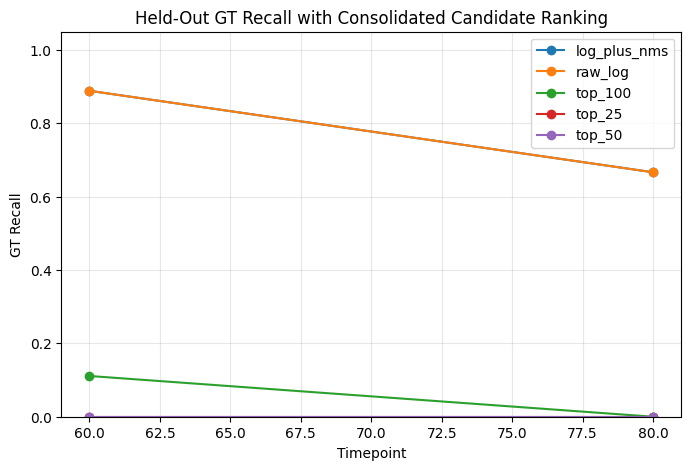

In [20]:
plt.figure(figsize=(8, 5))

for detector_name, group in heldout_results_df.groupby("detector"):
    plt.plot(group["t"], group["gt_recall"], marker="o", label=detector_name)

plt.title("Held-Out GT Recall with Consolidated Candidate Ranking")
plt.xlabel("Timepoint")
plt.ylabel("GT Recall")
plt.ylim(0, 1.05)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

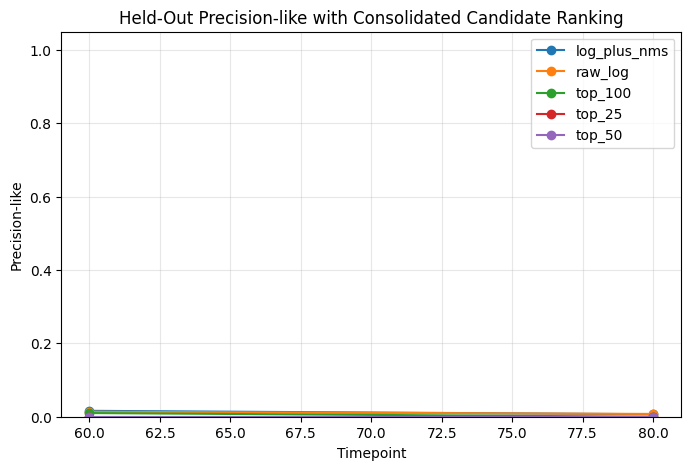

In [21]:
plt.figure(figsize=(8, 5))

for detector_name, group in heldout_results_df.groupby("detector"):
    plt.plot(group["t"], group["pred_precision_like"], marker="o", label=detector_name)

plt.title("Held-Out Precision-like with Consolidated Candidate Ranking")
plt.xlabel("Timepoint")
plt.ylabel("Precision-like")
plt.ylim(0, 1.05)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Step 8 — Visualize a Held-Out Timepoint

I will inspect `t = 60` using the top 50 consolidated-ranked candidates.

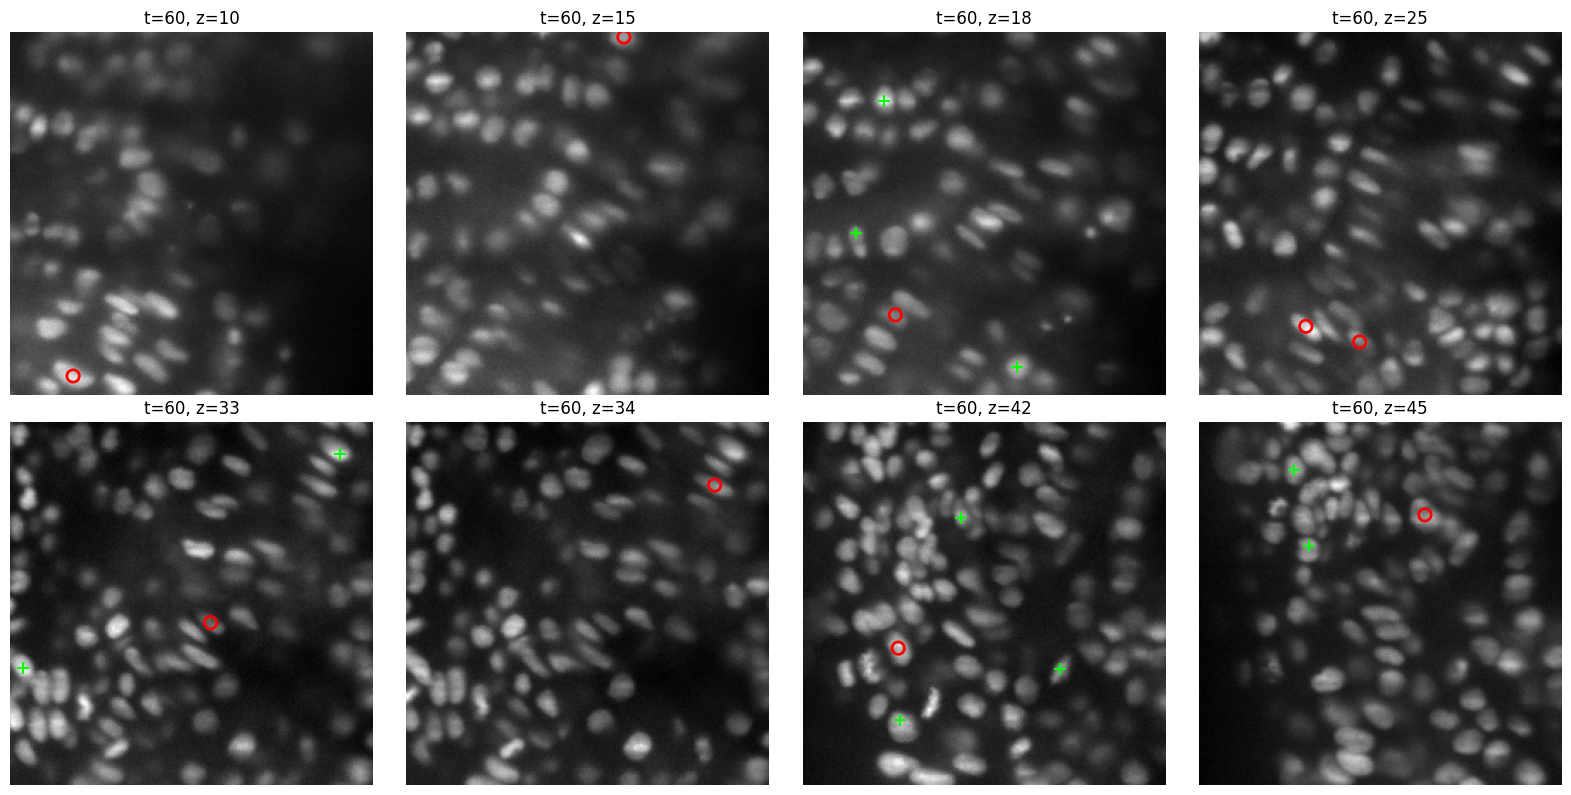

In [22]:
t_vis = 60
top_k_vis = 50

ranked_vis = heldout_ranked[t_vis]
gt_vis = heldout_gt[t_vis]
frame_vis = image[t_vis]

top_vis_df = ranked_vis.head(top_k_vis).copy()
gt_z_slices = sorted(gt_vis["z"].unique())

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for ax, z in zip(axes, gt_z_slices[:8]):
    slice_img = frame_vis[z]
    gt_slice = gt_vis[gt_vis["z"] == z]
    pred_slice = top_vis_df[top_vis_df["z"] == z]

    ax.imshow(slice_img, cmap="gray")

    ax.scatter(
        gt_slice["x"], gt_slice["y"],
        facecolors="none",
        edgecolors="red",
        s=80,
        linewidths=2
    )

    ax.scatter(
        pred_slice["x"], pred_slice["y"],
        c="lime",
        marker="+",
        s=70
    )

    ax.set_title(f"t={t_vis}, z={z}")
    ax.axis("off")

plt.tight_layout()
plt.show()

In [23]:
importance_df_nms = pd.DataFrame({
    "feature": feature_cols,
    "importance": ranker_nms.feature_importances_
}).sort_values("importance", ascending=False)

importance_df_nms

,feature,importance
7,patch_com_offset,0.223136
12,z_support_min,0.135560
2,patch_mean,0.105595
3,patch_max,0.085595
5,local_contrast,0.083027
10,z_support_mean,0.076857
11,z_support_std,0.076053
4,patch_std,0.070818
13,z_support_max,0.049720
1,center_intensity,0.034770


# Step 9 — Interpretation Guide

This chapter answers one question:

> Does NMS make ranking easier?

## If top-k improves
Then consolidation helped the ranking problem by reducing duplicates and clutter.

## If top-k still fails
Then the bottleneck is not just duplicate candidates. The model may still need:
- better features
- a different ranking target
- 3D patches instead of 2D patch features
- or a learned detector trained directly on image volumes.

## If log_plus_nms alone improves precision-like while preserving recall
Then NMS is useful even without a learned ranker.

# 📊 Results

3D NMS reduced the candidate pool while preserving raw LoG recall on held-out timepoints.

## Held-out average performance

### Raw LoG
- average candidates: 1907.5
- average GT recall: 0.7778
- average precision-like: 0.0106

### LoG + NMS
- average candidates: 845.5
- average GT recall: 0.7778
- average precision-like: 0.0114

### Ranked top-k after NMS
- top 25: average GT recall = 0.0
- top 50: average GT recall = 0.0
- top 100: average GT recall = 0.0556

# 🔍 Analysis

NMS is helpful as a candidate cleanup step, but it does not solve the learned ranking problem.

The strongest result is that `log_plus_nms` preserved the same average GT recall as raw LoG while reducing the candidate count from about 1907 to about 846.

However, the learned distance ranker still failed to select GT-near candidates in the top-k filtered sets. This means the main bottleneck is not only duplicate candidates. The handcrafted feature ranking model is still not learning a robust enough signal for held-out timepoints.

# 📝 What I Learned

Today I learned that:

- 3D NMS can dramatically reduce the LoG candidate count
- NMS radius 3 preserves held-out GT recall in this sample
- the best current non-learned detector is raw LoG + NMS
- learned top-k ranking still fails after consolidation
- the next step should focus on improving the scoring/ranking method, not just reducing duplicates